In [1]:
# making somewhat cleaned-up versions of figures for figure 4 + related supplementary figures; 

In [143]:
import os
import re
import importlib
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import cm
import matplotlib.font_manager
%matplotlib inline

import utils # ./utils.py
importlib.reload(utils)

<module 'utils' from '/Users/alyulina/Projects/Cancer/Figures/cleaning-up/utils.py'>

In [3]:
# pre-processed data:
# excluded samples: SK1_8 (very low coverage), SK1_11 (duplicate of SK1_10), LS01_17 (no spike-in detected), LS01_32 (no reads)
metadata = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/metadata.csv', index_col='sample id') # all sequencing samples
read_counts_by_cell_line = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/cell-line_read_counts.csv', index_col='clID')
cell_counts_by_cell_line = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/cell-line_cell_counts.csv', index_col='clID')

clIDs = utils.clIDs
clID__label = utils.clID__label
clID__color = utils.clID__color 

# where to find data:
path_to_reads = '/Users/alyulina/Projects/Cancer/Data/bc_counts/'

# where to save plots:
path_to_save_figs = '/Users/alyulina/Projects/Cancer/Figures/fig4/'

In [4]:
# note that the figures might change slightly each time you run this code, 
# so make sure to update annotations accordingly

### Organ tropism plots (second exp.)

In [6]:
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [7]:
what = ['2', 20, 'C57B6/129S F1', 'pancreas']
samples_pancreas = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [8]:
what = ['2', 20, 'C57B6/129S F1', 'liver']
samples_liver = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [9]:
clID__in_vivo_exp, clID__in_vivo_exp_avg_relative_to_mean, clID__in_vivo_exp_err, clIDs_sorted = utils.bootstrap_relative_burden(samples, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

clID__in_vivo_exp_pancreas, clID__in_vivo_exp_avg_pancreas_relative_to_mean, clID__in_vivo_exp_pancreas_err, clIDs_sorted_pancreas = utils.bootstrap_relative_burden(samples_pancreas, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_liver, clID__in_vivo_exp_avg_liver_relative_to_mean, clID__in_vivo_exp_liver_err, clIDs_sorted_liver = utils.bootstrap_relative_burden(samples_liver, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)


excluded: Spike-in 1
excluded: Panc02


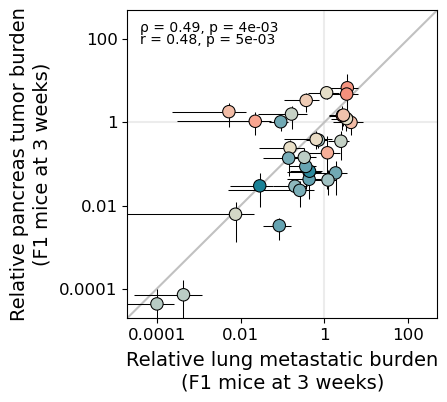

In [10]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                    clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                    clID__y=clID__in_vivo_exp_avg_pancreas_relative_to_mean, clID__yerr=clID__in_vivo_exp_pancreas_err,
                                    xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative pancreas tumor burden\n(F1 mice at 3 weeks)',
                                    lims=[2e-5, 0.5e3], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig(path_to_save_figs + 'fig4_relative_in_vivo_exp_vs_pancreas_exp2.pdf', dpi=300, bbox_inches='tight')  

excluded: Spike-in 1
excluded: Panc02


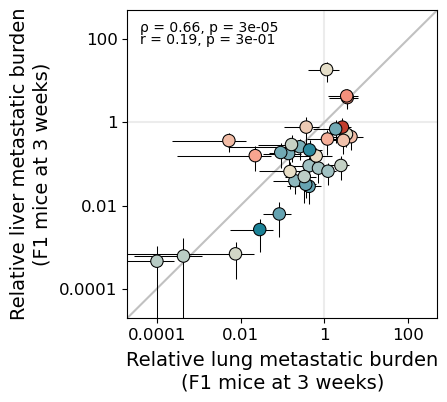

In [11]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                    clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                    clID__y=clID__in_vivo_exp_avg_liver_relative_to_mean, clID__yerr=clID__in_vivo_exp_liver_err,
                                    xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)',
                                    lims=[2e-5, 0.5e3], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig(path_to_save_figs +'fig4_relative_in_vivo_exp_vs_liver_exp2.pdf', dpi=300, bbox_inches='tight')  

excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


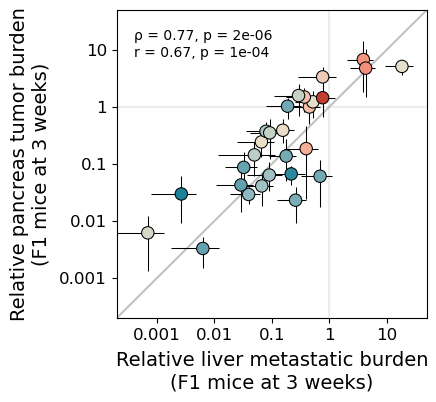

In [12]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                    clID__x=clID__in_vivo_exp_avg_liver_relative_to_mean, clID__xerr=clID__in_vivo_exp_liver_err,
                                    clID__y=clID__in_vivo_exp_avg_pancreas_relative_to_mean, clID__yerr=clID__in_vivo_exp_pancreas_err,
                                    xtitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative pancreas tumor burden\n(F1 mice at 3 weeks)',
                                    lims=[2e-4, 0.5e2], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1], labels=['0.001', '0.01', '0.1', '1', '10'])

#plt.savefig(path_to_save_figs + 'fig4_relative_exp_liver_vs_pancreas_exp2.pdf', dpi=300, bbox_inches='tight')  

excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


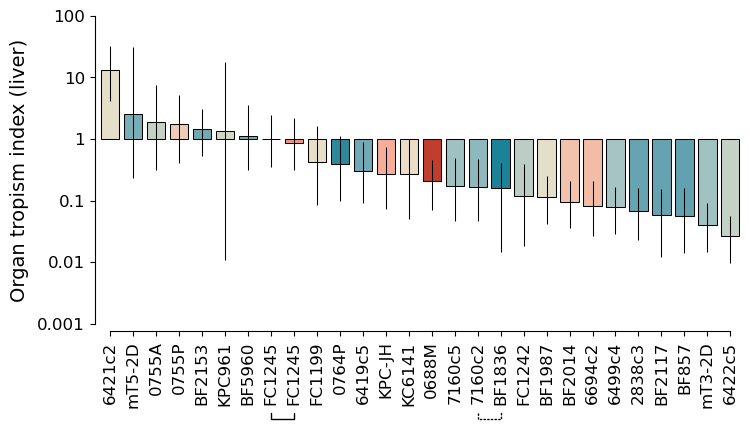

In [13]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

# calculating organ tropism index: liver
clID__liver_index_distr = {}
clID__liver_index_avg_relative_to_mean = {}
clID__liver_index_err = {}
for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    clID__liver_index_distr[clID] = clID__in_vivo_exp_liver[clID] / (clID__in_vivo_exp[clID] + 1e-12)
    
y_mean = np.mean([np.mean(clID__liver_index_distr[clID]) for clID in clIDs if clID not in excluded_clIDs])

for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    y = np.mean(clID__liver_index_distr[clID])
    
    ci_upper = np.percentile(clID__liver_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__liver_index_distr[clID], 2.5)
    clID__liver_index_err[clID] = [(y - ci_lower) / y_mean, (ci_upper - y) / y_mean]
    clID__liver_index_avg_relative_to_mean[clID] = y / y_mean
    
clIDs_sorted = [y[0] for y in sorted([[x, clID__liver_index_avg_relative_to_mean[x]] for x in clIDs if x not in excluded_clIDs], key = lambda x: x[-1], reverse=True)]

ax = utils.metric_bar_plot(clIDs_sorted, clID__liver_index_avg_relative_to_mean, clID__liver_index_err, 
                           ytitle='Organ tropism index (liver)', 
                           ylims=[1e-3, 1e2], yticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['0.001', '0.01', '0.1', '1', '10', '100'])

ax.annotate('', xy=(7, 0.00004), xycoords='data', xytext=(8, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(16, 0.00004), xycoords='data', xytext=(17, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

#plt.savefig(path_to_save_figs + 'fig4_liver_index.pdf', dpi=300, bbox_inches='tight')  


excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


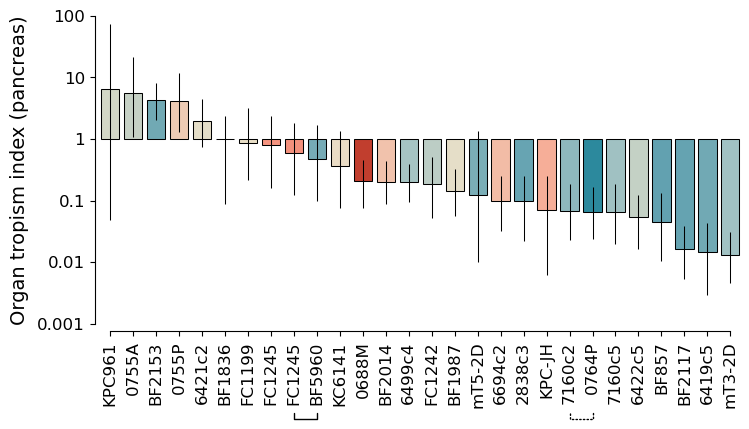

In [14]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

# calculating organ tropism index: pancreas
clID__pancreas_index_distr = {}
clID__pancreas_index_avg_relative_to_mean = {}
clID__pancreas_index_err = {}
for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    clID__pancreas_index_distr[clID] = clID__in_vivo_exp_pancreas[clID] / clID__in_vivo_exp[clID]
    
y_mean = np.mean([np.mean(clID__pancreas_index_distr[clID]) for clID in clIDs if clID not in excluded_clIDs])

for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    y = np.mean(clID__pancreas_index_distr[clID])
    
    ci_upper = np.percentile(clID__pancreas_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__pancreas_index_distr[clID], 2.5)
    clID__pancreas_index_err[clID] = [(y - ci_lower) / y_mean, (ci_upper - y) / y_mean]
    clID__pancreas_index_avg_relative_to_mean[clID] = y / y_mean
    
clIDs_sorted = [y[0] for y in sorted([[x, clID__pancreas_index_avg_relative_to_mean[x]] for x in clIDs if x not in excluded_clIDs], key = lambda x: x[-1], reverse=True)]

ax = utils.metric_bar_plot(clIDs_sorted, clID__pancreas_index_avg_relative_to_mean, clID__pancreas_index_err, 
                      ytitle='Organ tropism index (pancreas)', 
                     ylims=[1e-3, 1e2], yticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['0.001', '0.01', '0.1', '1', '10', '100'])

ax.annotate('', xy=(8, 0.00004), xycoords='data', xytext=(9, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(20, 0.00004), xycoords='data', xytext=(21, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

#plt.savefig(path_to_save_figs + 'fig4_pancreas_index.pdf', dpi=300, bbox_inches='tight')  


### Supplementary figures: immune rejection plots

In [15]:
# making a list of 3w F1 iv lung samples from exp. two (again, just in case)
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [16]:
# making a list of 3w Rag1 iv lung samples from exp. two
what = ['2', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_wo_immune_system = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['injection method'] == what[3]) & 
                                   (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [17]:
clID__in_vivo_exp, clID__in_vivo_exp_avg_relative_to_mean, clID__in_vivo_exp_err, clIDs_sorted = utils.bootstrap_relative_burden(samples, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_wo_immune_system, clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean, clID__in_vivo_exp_wo_immune_system_err, clIDs_sorted_wo_immune_system = utils.bootstrap_relative_burden(samples_wo_immune_system, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)


excluded: Spike-in 1
excluded: Panc02


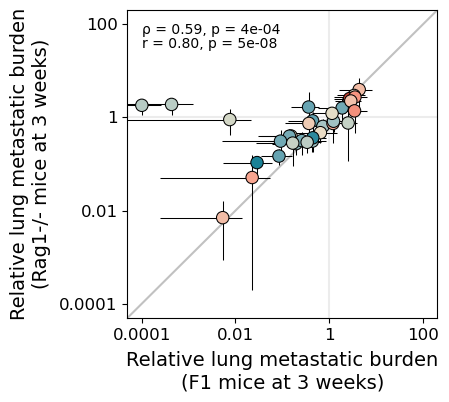

In [18]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                   clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                   clID__y=clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean, clID__yerr=clID__in_vivo_exp_wo_immune_system_err,
                                   xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks)',
                                   lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

plt.savefig(path_to_save_figs + 'fig4_si_relative_in_vivo_exp_w_and_wo_immune_system_exp2.pdf', dpi=300, bbox_inches='tight')  

In [19]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

# calculating immune rejection index
clID__immune_rejection_index_distr = {}
clID__immune_rejection_index_avg_relative_to_mean = {}
clID__immune_rejection_index_err = {}
for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    clID__immune_rejection_index_distr[clID] = clID__in_vivo_exp_wo_immune_system[clID] / clID__in_vivo_exp[clID]
    
y_mean = np.mean([np.mean(clID__immune_rejection_index_distr[clID]) for clID in clIDs if clID not in excluded_clIDs])

for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    y = np.mean(clID__immune_rejection_index_distr[clID])
    
    ci_upper = np.percentile(clID__immune_rejection_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__immune_rejection_index_distr[clID], 2.5)
    clID__immune_rejection_index_err[clID] = [(y - ci_lower) / y_mean, (ci_upper - y) / y_mean]
    clID__immune_rejection_index_avg_relative_to_mean[clID] = y / y_mean
    
clIDs_sorted_immune_rejection_index = [y[0] for y in sorted([[x, clID__immune_rejection_index_avg_relative_to_mean[x]] for x in clIDs if x not in excluded_clIDs], key = lambda x: x[-1], reverse=True)]

excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


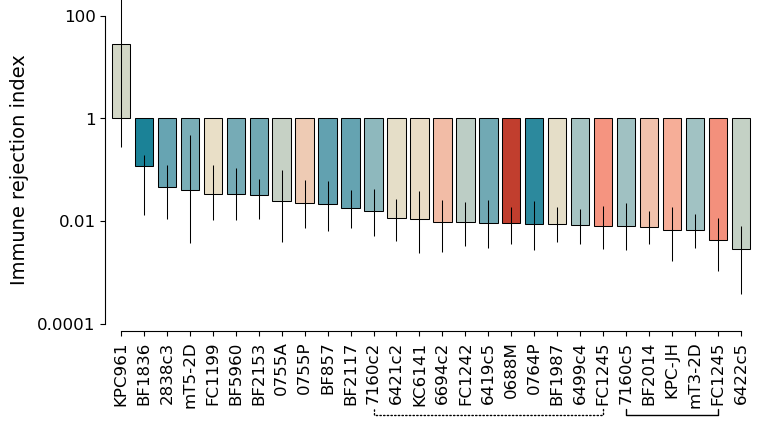

In [20]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.metric_bar_plot(clIDs_sorted_immune_rejection_index, clID__immune_rejection_index_avg_relative_to_mean, clID__immune_rejection_index_err, 
                          ytitle='Immune rejection index', 
                          ylims=[1e-4, 1e2], yticks=[1e-4, 1e-2, 1e0, 1e2], ylabels=['0.0001', '0.01', '1', '100'])

ax.annotate('', xy=(22, 0.0000025), xycoords='data', xytext=(26, 0.0000025), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.1'), 
            annotation_clip=False);

ax.annotate('', xy=(11, 0.0000025), xycoords='data', xytext=(21, 0.0000025), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.04'), 
            annotation_clip=False);

#plt.savefig(path_to_save_figs + 'fig4_si_immune_rejection_index_exp2.pdf', dpi=300, bbox_inches='tight')  


### Supplementary figures: in vitro comparisons

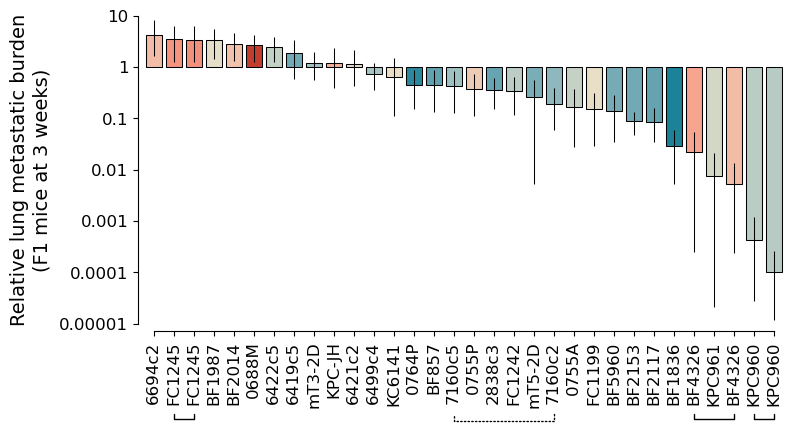

In [21]:
ax = utils.metric_bar_plot(clIDs_sorted[:-1], clID__in_vivo_exp_avg_relative_to_mean, clID__in_vivo_exp_err, 
                          ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', 
                          ylims=[1e-5, 1e1], yticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], ylabels=['0.00001', '0.0001', '0.001', '0.01', '0.1', '1', '10'])


ax.annotate('', xy=(1, 0.0000002), xycoords='data', xytext=(2, 0.0000002), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(27, 0.0000002), xycoords='data', xytext=(29, 0.0000002), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.2'), 
            annotation_clip=False);

ax.annotate('', xy=(30, 0.0000002), xycoords='data', xytext=(31, 0.0000002), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(15, 0.0000002), xycoords='data', xytext=(20, 0.0000002), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.1'), 
            annotation_clip=False);

#plt.savefig(path_to_save_figs + 'fig4_si_relative_in_vivo_exp.pdf', dpi=300, bbox_inches='tight')  


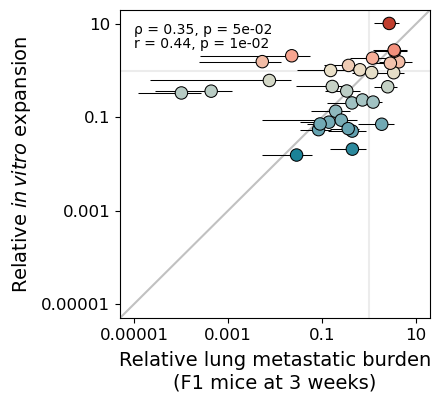

In [22]:
in_vitro_samples = metadata.loc[metadata['experiment'] == 'in vitro'].groupby('time point, d').apply(lambda df: df.index.tolist()) 
clIDs_ordered_in_vitro = ['AGGT', 'AGCA', 'CTTC', 'AGTC', 'ATCG', 'GAAG', 'CACT', 'ACCT', 'CCTT', 'CATG', 'GGAA', 'ACAC', 'GTTG', 'AGAG', 'TTGG', 'TCCA', 'CTGT', 'TTCC', 'CAGA', 'GCAT', 'CGTA', 'GGTT', 'ACGA', 'AAGG', 'GTAC', 'CGAT', 'GCTA', 'CAAC', 'TGAC', 'ATGC', 'ACTG', 'GTGA', 'CCAA'] # clIDs sorted by weighted avg expansion in vitro


clID__in_vitro_exp = {}
clID__in_vitro_exp_err = {}
for clID in clIDs_ordered_in_vitro:
     
    t = 3 # normalizing by the fraction at t = 3 days 
    norm = np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])

    t = 23 # last time point
    y = [read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) / norm for sample_id in in_vitro_samples[t]]
    
    clID__in_vitro_exp[clID] = np.mean(y)
    clID__in_vitro_exp_err[clID] = [np.std(y), np.std(y)]
    
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                   clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                   clID__y=clID__in_vitro_exp, clID__yerr=clID__in_vitro_exp_err,
                                   xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative ' + '$\it{in\,vitro}$' + ' expansion',
                                   lims=[5e-6, 0.2e2], ticks=[1e-5, 1e-3, 1e-1, 1e1], labels=['0.00001', '0.001', '0.1', '10'])

#plt.savefig(path_to_save_figs + 'fig4_si_relative_in_vivo_exp_vs_relative_in_vitro_expansion.pdf', dpi=300, bbox_inches='tight')  

### Experiment vs experiment comparisons

In [23]:
# 3 week F1 mice:

what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = utils.bootstrap_relative_burden(samples_1, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = utils.bootstrap_relative_burden(samples_2, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

excluded: Spike-in 1
excluded: Panc02


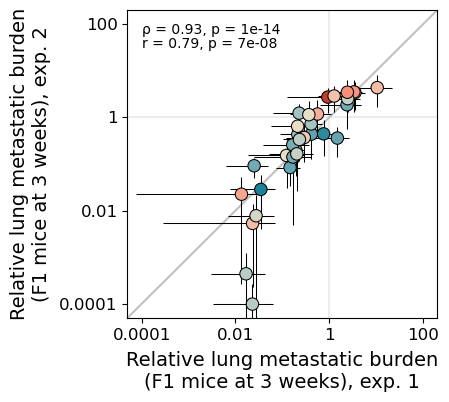

In [24]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                   clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                                   clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                                   xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks), exp. 1', ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks), exp. 2',
                                   lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

plt.savefig(path_to_save_figs + 'fig4_si_exp_1vs_2_3w_f1_iv_lung.pdf', dpi=300, bbox_inches='tight')  

In [25]:
# 3 week Rag1 mice:

what = ['1', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = utils.bootstrap_relative_burden(samples_1, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = utils.bootstrap_relative_burden(samples_2, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

excluded: Spike-in 1
excluded: Panc02


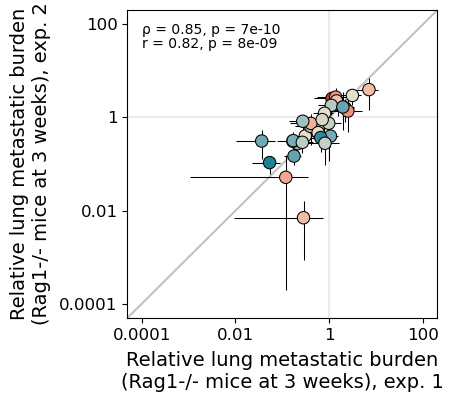

In [26]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                   clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                                   clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                                   xtitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks), exp. 1', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks), exp. 2',
                                   lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig(path_to_save_figs + '/fig4_si_exp_1vs_2_3w_rag1_iv_lung.pdf', dpi=300, bbox_inches='tight')  

In [27]:
what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'liver']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intrasplenic', 'liver']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = utils.bootstrap_relative_burden(samples_1, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = utils.bootstrap_relative_burden(samples_2, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

excluded: Spike-in 1
excluded: Panc02


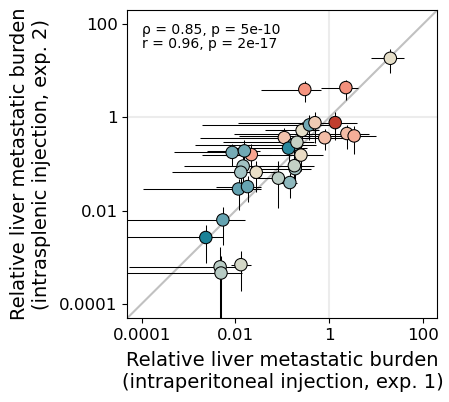

In [28]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                    clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                                    clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                                    xtitle='Relative liver metastatic burden\n(intraperitoneal injection, exp. 1)', ytitle='Relative liver metastatic burden\n(intrasplenic injection, exp. 2)',
                                    lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig(path_to_save_figs + 'fig4_si_exp_1vs_2_liver.pdf', dpi=300, bbox_inches='tight')  

In [29]:
what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'pancreas']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intrapancreatic', 'pancreas']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = utils.bootstrap_relative_burden(samples_1, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = utils.bootstrap_relative_burden(samples_2, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

excluded: Spike-in 1
excluded: Panc02


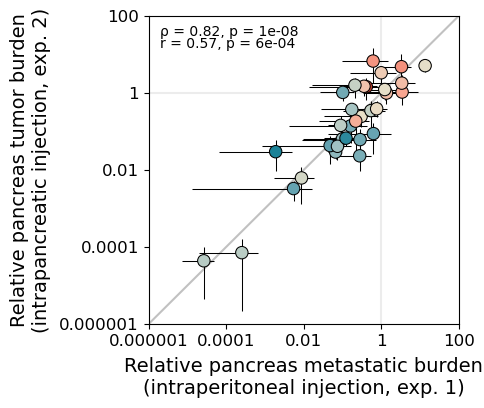

In [30]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                    clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                                    clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                                    xtitle='Relative pancreas metastatic burden\n(intraperitoneal injection, exp. 1)', ytitle='Relative pancreas tumor burden\n(intrapancreatic injection, exp. 2)',
                                    lims=[1e-6, 1e2], ticks=[1e-6, 1e-4, 1e-2, 1e0, 1e2], labels=['0.000001', '0.0001', '0.01', '1', '100'])

#plt.savefig(path_to_save_figs + 'fig4_si_exp_1vs_2_pancreas.pdf', dpi=300, bbox_inches='tight')  

### Rank order plot 

In [107]:
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [149]:
_, clID__in_vivo_exp_avg_relative_to_mean, _, clIDs_sorted = utils.bootstrap_relative_burden(samples, 
                                                                                             read_counts=read_counts_by_cell_line, 
                                                                                             cell_counts=cell_counts_by_cell_line, 
                                                                                             metadata=metadata)


In [109]:
def sigmoid(xs, ys, smooth=8, n=100):
    """
    Interpolates a sigmoid function between x and y coordinates.
    
    Args:
        xs (array-like): Start and stop positions for the x-values.
        ys (array-like): Start and stop positions for the y-values.
        smooth (int, optional): Steepness of the sigmoid function's slope. Default is 8.
        n (int, optional): Number of interpolation points. Default is 100.

    Returns:
        tuple: Interpolated x and y values.
    """
    (x_from, x_to), (y_from, y_to) = xs, ys
    xs = np.linspace(-smooth, smooth, num=n)[:, None]
    ys = np.exp(xs) / (np.exp(xs) + 1)
    
    return ((ys * (x_to - x_from) + x_from), ((xs + smooth) / (smooth * 2) * (y_to - y_from) + y_from))



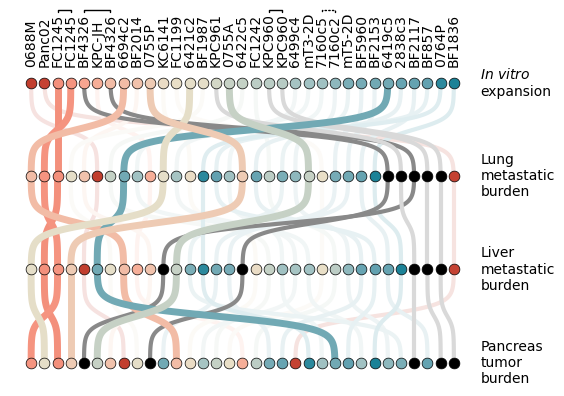

In [185]:
# setting up:

data = [[i for i in range(len(clIDs_ordered_in_vitro))],
        [clIDs_sorted.index(i) for i in clIDs_ordered_in_vitro],
        [clIDs_sorted_liver.index(i) for i in clIDs_ordered_in_vitro],
        [clIDs_sorted_pancreas.index(i) for i in clIDs_ordered_in_vitro]]

n_js = len(clIDs_ordered_in_vitro)
n_environments = len(data)

fig, ax = plt.subplots(figsize=(6, 4))
ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)

highlight = ['ACCT', 'AGTC', 'CAAC', 'CTTC', 'GTTG', 'CATG', 'TCCA']
clID__z_order = {'ACCT': 6, 'AGTC': 5, 'CAAC': 7, 'CTTC': 4, 'GTTG': 8, 'CATG': 10, 'TCCA': 9}

# loop through each cell line and interpolate its rank transitions
for j in range(n_js):
    
    clID = clIDs_ordered_in_vitro[j]
    
    if clIDs_ordered_in_vitro[j] in highlight:
        c = clID__color[clID]
        z = clID__z_order[clID]
        l = 5
    else:
        c = tuple(0.15 * np.array(clID__color[clID]) + 0.85 * np.array([1, 1, 1, 1]))
        z = -1e3
        l = 3
    
    if clIDs_ordered_in_vitro[j] in ['TTGG', 'CAGA', 'GCAT']:
        c = '#d9d9d9'
        z = -len(highlight)
        C = 'black'
    elif clIDs_ordered_in_vitro[j] in ['ATCG', 'CACT']:
        c = '#898989'
        z = -len(highlight)
        C = 'black'
    else:
        C = clID__color[clIDs_ordered_in_vitro[j]]
    
    plt.scatter(data[0][j], 0, color=clID__color[clID], s=60, edgecolor='black', linewidth=0.5, zorder=1e3)
    plt.text(data[0][j], -0.2, clID__label[clID], rotation=90, fontsize=10, ha='center')
    
    for i in range(n_environments - 1):
        x_values = [data[i][j], data[i + 1][j]]  # rank positions
        y_values = [i, (i + 1)]  # environments
        
        # use sigmoid interpolation (environment on y-axis, rank on x-axis)
        interp_x, interp_y = sigmoid(x_values, y_values, smooth=8, n=100)

        # plot smooth transition (rank on x-axis, environment on y-axis)
        plt.plot(interp_x, interp_y, color=c, linewidth=l, zorder=z)
        plt.scatter(data[i + 1][j], i + 1, color=C, s=60, edgecolor='black', linewidth=0.5, zorder=1e3)


plt.text(34, 0, '$In$' + ' ' + '$vitro$' + '\nexpansion', va='center')
plt.text(34, 1, 'Lung\nmetastatic\nburden', va='center')
plt.text(34, 2, 'Liver\nmetastatic\nburden', va='center')
plt.text(34, 3, 'Pancreas\ntumor\nburden', va='center')

         
plt.gca().invert_yaxis()  # flip y-axis so first environment is at the top

plt.xticks([]);
plt.yticks([]);

ax.annotate('', xy=(2, -0.725), xycoords='data', xytext=(3, -0.725), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(4, -0.725), xycoords='data', xytext=(6, -0.725), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=0.2'), 
            annotation_clip=False);

ax.annotate('', xy=(18, -0.725), xycoords='data', xytext=(19, -0.725), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(22, -0.725), xycoords='data', xytext=(23, -0.725), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=0.4'), 
            annotation_clip=False);

#plt.savefig(path_to_save_figs + 'fig4_rank_order_plot.pdf', dpi=300, bbox_inches='tight')  

### PCA plot

In [150]:
# trying to do PCA 
data = pd.DataFrame({'lung': clID__in_vivo_exp_avg_relative_to_mean, 
                     'liver': clID__in_vivo_exp_avg_liver_relative_to_mean, 
                     'pancreas': clID__in_vivo_exp_avg_pancreas_relative_to_mean})

pca = PCA(n_components=3)
components = pca.fit_transform(StandardScaler().fit_transform(data))
components_dict = dict(zip(list(data.index), components))

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
var_explained = pca.explained_variance_ratio_

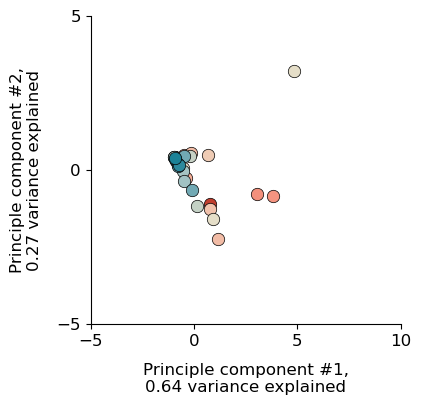

In [181]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.spines[['top', 'right']].set_visible(False)

c = 0
for count, i in enumerate(clIDs_ordered_in_vitro):

    plt.scatter(components_dict[i][c + 0], components_dict[i][c + 1], color=clID__color[i], s=80, edgecolor='black', linewidth=0.5, alpha=1)
    #plt.text(components_dict[i][c + 0], components_dict[i][c + 1], clID__label[i])
    
    plt.xticks([-5, 0, 5, 10], size=12);
    plt.yticks([-5, 0, 5], size=12);
    plt.xlim(-5, 10);
    plt.ylim(-5, 5);
        

plt.xlabel('Principle component #%.0f,\n%.2f variance explained' % (c + 1, var_explained[c + 0]), fontsize=12, labelpad=10);
plt.ylabel('Principle component #%.0f,\n%.2f variance explained' % (c + 2, var_explained[c + 1]), fontsize=12, labelpad=10);


#plt.savefig(path_to_save_figs + 'fig4_pca.pdf', dpi=300, bbox_inches='tight')  

### Supplementary figures: tumor size distributions

In [186]:
# making a list of 3w F1 iv lung samples from exp. one
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

print(len(samples))

10


In [187]:
clID__percentiles, clID__ci = utils.bootstrap_tumor_size_percentiles(samples,
                                                                     path_to_data=path_to_reads,
                                                                     percentiles=[50, 60, 70, 80, 90, 99],
                                                                     read_counts=read_counts_by_cell_line,
                                                                     metadata=metadata)

In [188]:
_, _, _, clIDs_sorted = utils.bootstrap_relative_burden(samples, 
                                                        read_counts=read_counts_by_cell_line, 
                                                        cell_counts=cell_counts_by_cell_line, 
                                                        metadata=metadata)


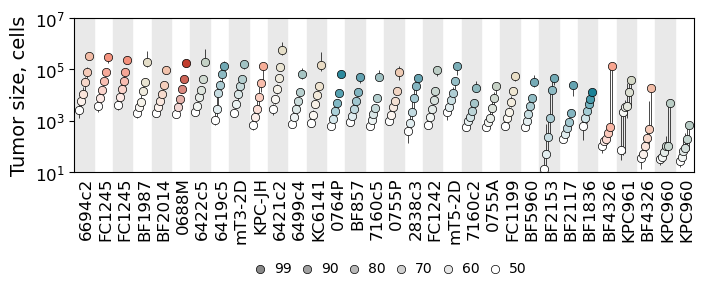

In [198]:
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted[:-1]):
    rgb = np.array(clID__color[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(clID__percentiles[clID]))
    for j, p in enumerate(clID__percentiles[clID]):
        plt.scatter(i + j * 0.1, clID__percentiles[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5)
        plt.errorbar(i + j * 0.1, clID__percentiles[clID][j],  [[clID__percentiles[clID][j] - clID__ci[clID][0][j]], [clID__ci[clID][1][j] - clID__percentiles[clID][j]]], color='black', linewidth=0.5, zorder=-1)
    if i % 2 == 0:
        plt.fill_between([i - 0.25, i + j * 0.1 + 0.25], 1e1, 1e7, color='#e9e9e9', zorder=-2)
        
# for legend:
gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(clID__percentiles[clID]))[::-1]
for j, p in enumerate([50, 60, 70, 80, 90, 99][::-1]):
    plt.scatter(-1, clID__percentiles[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5, label=p)
    
plt.yscale('log')
plt.minorticks_off()

plt.legend(frameon=False, bbox_to_anchor=(0.75, -0.5), ncol=len(gradient), handletextpad=0, columnspacing=0.1)

plt.ylim(1e1, 1e7)
plt.xlim(-0.25, i + j * 0.1 + 0.25)
plt.yticks(size=12)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='left', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

#plt.savefig(path_to_save_figs + 'fig4_tumor_size_distr_lung.pdf', dpi=300, bbox_inches='tight')  

In [191]:
what = ['2', 20, 'C57B6/129S F1', 'pancreas']
samples_pancreas = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


what = ['2', 20, 'C57B6/129S F1', 'liver']
samples_liver = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [192]:
clID__percentiles_pancreas, clID__ci_pancreas = utils.bootstrap_tumor_size_percentiles(samples_pancreas,
                                                                                       path_to_data=path_to_reads,
                                                                                       percentiles=[50, 60, 70, 80, 90, 99],
                                                                                       read_counts=read_counts_by_cell_line,
                                                                                       metadata=metadata)

In [193]:
clID__percentiles_liver, clID__ci_liver = utils.bootstrap_tumor_size_percentiles(samples_liver,
                                                                                 path_to_data=path_to_reads,
                                                                                 percentiles=[50, 60, 70, 80, 90, 99],
                                                                                 read_counts=read_counts_by_cell_line,
                                                                                 metadata=metadata)

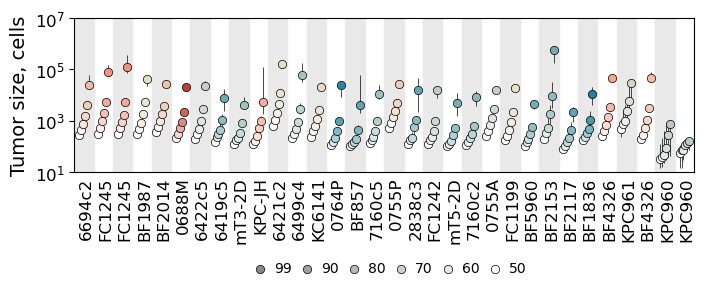

In [199]:
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted[:-1]):
    rgb = np.array(clID__color[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(clID__percentiles_pancreas[clID]))
    for j, p in enumerate(clID__percentiles_pancreas[clID]):
        plt.scatter(i + j * 0.1, clID__percentiles_pancreas[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5)
        plt.errorbar(i + j * 0.1, clID__percentiles_pancreas[clID][j],  [[clID__percentiles_pancreas[clID][j] - clID__ci_pancreas[clID][0][j]], [clID__ci_pancreas[clID][1][j] - clID__percentiles_pancreas[clID][j]]], color='black', linewidth=0.5, zorder=-1)
    if i % 2 == 0:
        plt.fill_between([i - 0.25, i + j * 0.1 + 0.25], 1e1, 1e7, color='#e9e9e9', zorder=-2)
        
# for legend:
gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(clID__percentiles_pancreas[clID]))[::-1]
for j, p in enumerate([50, 60, 70, 80, 90, 99][::-1]):
    plt.scatter(-1, clID__percentiles_pancreas[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5, label=p)
    
plt.yscale('log')
plt.minorticks_off()

plt.legend(frameon=False, bbox_to_anchor=(0.75, -0.5), ncol=len(gradient), handletextpad=0, columnspacing=0.1)

plt.ylim(1e1, 1e7)
plt.xlim(-0.25, i + j * 0.1 + 0.25)
plt.yticks(size=12)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='left', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

#plt.savefig(path_to_save_figs + 'fig4_tumor_size_distr_pancreas.pdf', dpi=300, bbox_inches='tight')  

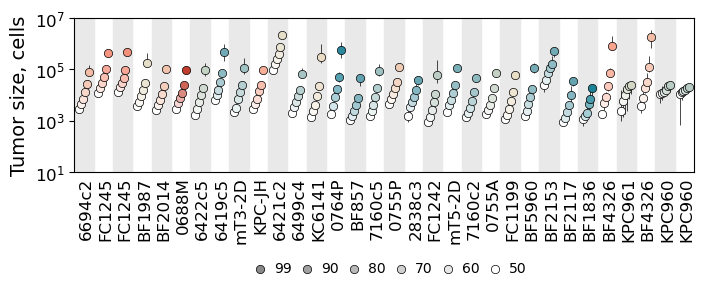

In [200]:
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted[:-1]):
    rgb = np.array(clID__color[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(clID__percentiles_liver[clID]))
    for j, p in enumerate(clID__percentiles_liver[clID]):
        plt.scatter(i + j * 0.1, clID__percentiles_liver[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5)
        plt.errorbar(i + j * 0.1, clID__percentiles_liver[clID][j],  [[clID__percentiles_liver[clID][j] - clID__ci_liver[clID][0][j]], [clID__ci_liver[clID][1][j] - clID__percentiles_liver[clID][j]]], color='black', linewidth=0.5, zorder=-1)
    if i % 2 == 0:
        plt.fill_between([i - 0.25, i + j * 0.1 + 0.25], 1e1, 1e7, color='#e9e9e9', zorder=-2)
        
# for legend:
gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(clID__percentiles_liver[clID]))[::-1]
for j, p in enumerate([50, 60, 70, 80, 90, 99][::-1]):
    plt.scatter(-1, clID__percentiles_liver[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5, label=p)
    
plt.yscale('log')
plt.minorticks_off()

plt.legend(frameon=False, bbox_to_anchor=(0.75, -0.5), ncol=len(gradient), handletextpad=0, columnspacing=0.1)

plt.ylim(1e1, 1e7)
plt.xlim(-0.25, i + j * 0.1 + 0.25)
plt.yticks(size=12)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='left', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

#plt.savefig(path_to_save_figs + 'fig4_tumor_size_distr_liver.pdf', dpi=300, bbox_inches='tight')  